In [2]:
import pandas as pd

In [3]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
combined_df = pd.read_csv('C:/Users/University/DATA SCI & BUSINESS/Processed_data/crude_pertroleum_import.csv')

In [5]:
print(combined_df.info())  # Check data types and non-null counts

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 745 entries, 0 to 744
Data columns (total 19 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   refYear               745 non-null    int64  
 1   reporterCode          745 non-null    int64  
 2   reporterISO           745 non-null    object 
 3   reporterDesc          745 non-null    object 
 4   classificationCode    745 non-null    object 
 5   cmdCode               745 non-null    int64  
 6   cmdDesc               745 non-null    object 
 7   qtyUnitCode           745 non-null    int64  
 8   qtyUnitAbbr           745 non-null    object 
 9   qty                   745 non-null    float64
 10  altQtyUnitCode        745 non-null    int64  
 11  altQtyUnitAbbr        745 non-null    object 
 12  altQty                745 non-null    float64
 13  netWgt                745 non-null    float64
 14  grossWgt              745 non-null    float64
 15  cifvalue              7

In [6]:
print(combined_df.describe())  # Summary statistics

           refYear  reporterCode  cmdCode  qtyUnitCode           qty  \
count   745.000000    745.000000    745.0   745.000000  7.450000e+02   
mean   2021.365101    423.923490   2709.0     6.381208  1.663973e+10   
std       1.688311    254.665732      0.0     3.459003  6.343497e+10   
min    2019.000000      4.000000   2709.0    -1.000000  0.000000e+00   
25%    2020.000000    203.000000   2709.0     8.000000  8.960000e+01   
50%    2021.000000    417.000000   2709.0     8.000000  3.108820e+05   
75%    2023.000000    642.000000   2709.0     8.000000  5.238160e+09   
max    2024.000000    894.000000   2709.0     8.000000  5.539918e+11   

       altQtyUnitCode        altQty        netWgt      grossWgt      cifvalue  \
count      745.000000  7.450000e+02  7.450000e+02  7.450000e+02  7.450000e+02   
mean         5.281879  8.488917e+09  1.574693e+10  1.058240e+08  9.418375e+09   
std          5.773364  4.434079e+10  6.228746e+10  9.486809e+08  3.329831e+10   
min         -1.000000  0.00

In [7]:
missing_values = combined_df.isnull().sum()
print("Missing values:\n", missing_values)


Missing values:
 refYear                 0
reporterCode            0
reporterISO             0
reporterDesc            0
classificationCode      0
cmdCode                 0
cmdDesc                 0
qtyUnitCode             0
qtyUnitAbbr             0
qty                     0
altQtyUnitCode          0
altQtyUnitAbbr          0
altQty                  0
netWgt                  0
grossWgt                0
cifvalue                0
fobvalue                0
primaryValue            0
legacyEstimationFlag    0
dtype: int64


In [8]:
duplicates = combined_df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [9]:
# Rename multiple columns
combined_df.rename(columns={
    'reporterdesc': 'reporterDesc',
    'refyear': 'refYear',
    'alt_qty': 'altQty'
}, inplace=True)

grouped_data = combined_df.groupby(['reporterDesc', 'refYear'])['cifvalue'].sum().reset_index()
grouped_data.head()

,reporterDesc,refYear,cifvalue
0,Afghanistan,2019,3.437247e+07
1,Andorra,2019,1.207124e+04
2,Andorra,2020,7.296400e+02
3,Andorra,2021,5.733593e+03
4,Andorra,2022,1.064122e+03


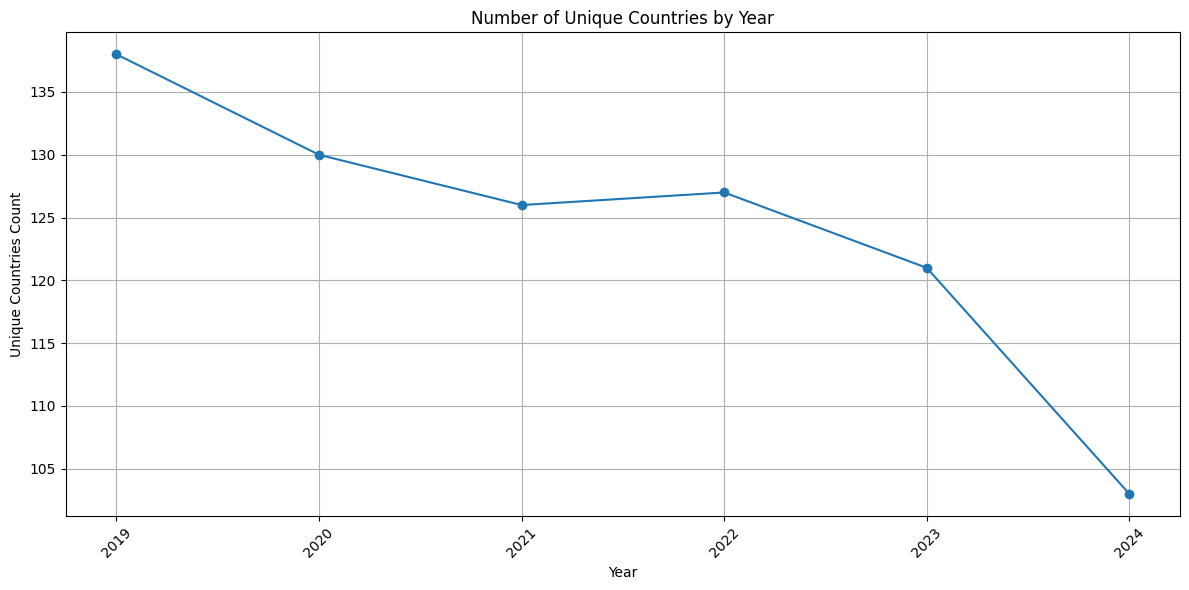

In [10]:
# Group by year and count unique countries
unique_countries_per_year = combined_df.groupby('refYear')['reporterDesc'].nunique().reset_index()

# Rename the columns for clarity
unique_countries_per_year.columns = ['Year', 'Unique Countries Count']

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(unique_countries_per_year['Year'], unique_countries_per_year['Unique Countries Count'], marker='o')
plt.title('Number of Unique Countries by Year')
plt.xlabel('Year')
plt.ylabel('Unique Countries Count')
plt.xticks(ticks=unique_countries_per_year['Year'], labels=unique_countries_per_year['Year'].astype(int), rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

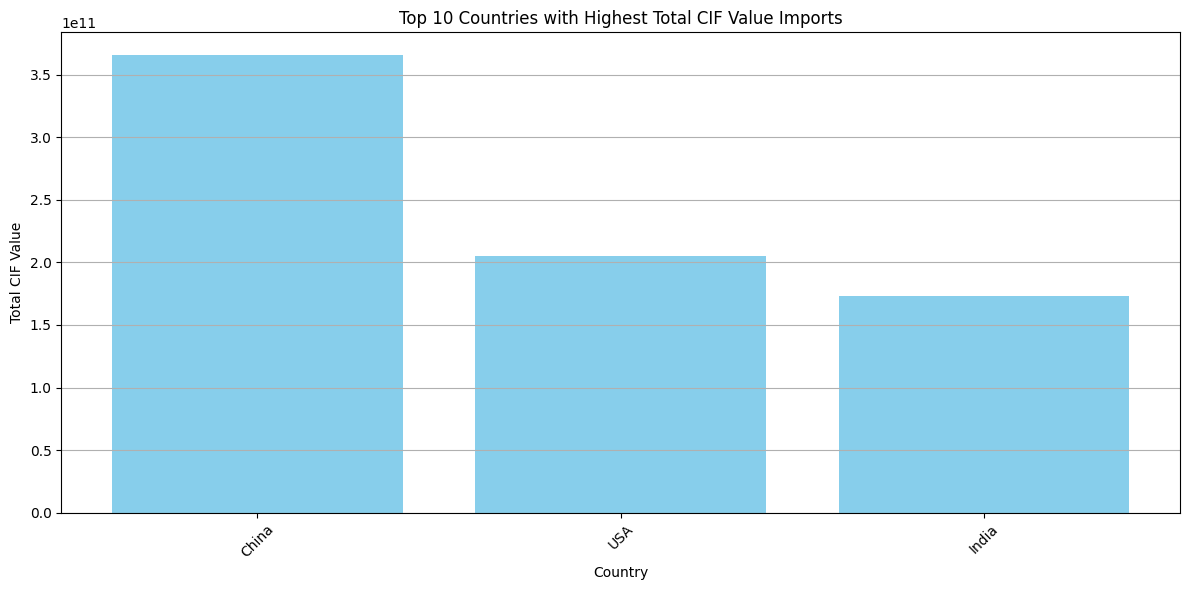

In [11]:
top_countries = grouped_data.sort_values(by='cifvalue', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_countries['reporterDesc'], top_countries['cifvalue'], color='skyblue')
plt.title('Top 10 Countries with Highest Total CIF Value Imports')
plt.xlabel('Country')
plt.ylabel('Total CIF Value')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

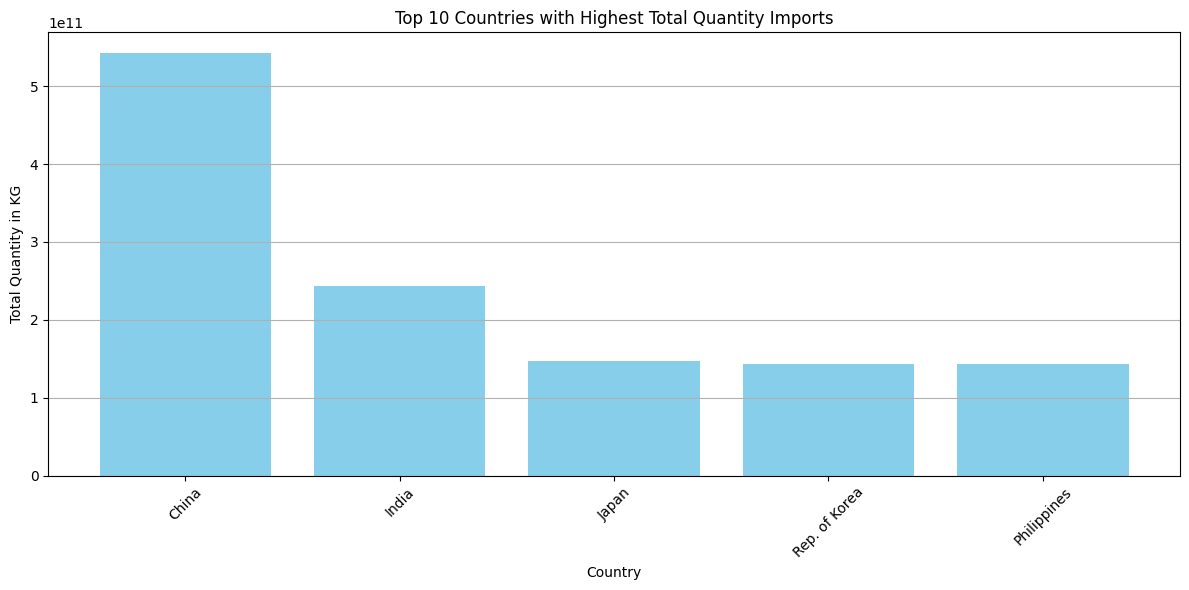

In [12]:
# Grouping the data by quantity
grouped_data_qty = combined_df.groupby(['reporterDesc', 'refYear'])['altQty'].sum().reset_index()

top_countries_qty = grouped_data_qty.sort_values(by='altQty', ascending=False).head(10)

plt.figure(figsize=(12, 6))
plt.bar(top_countries_qty['reporterDesc'], top_countries_qty['altQty'], color='skyblue')
plt.title('Top 10 Countries with Highest Total Quantity Imports')
plt.xlabel('Country')
plt.ylabel('Total Quantity in KG')
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()

In [13]:
# data cleaning
data = combined_df[['refYear', 'reporterDesc', 'cifvalue']].dropna()

In [14]:
# Group by country and year, summing the cifvalue for each combination
grouped_data = data.groupby(['reporterDesc', 'refYear']).sum().reset_index()

In [15]:
# Prepare to store future predictions
future_results = pd.DataFrame()

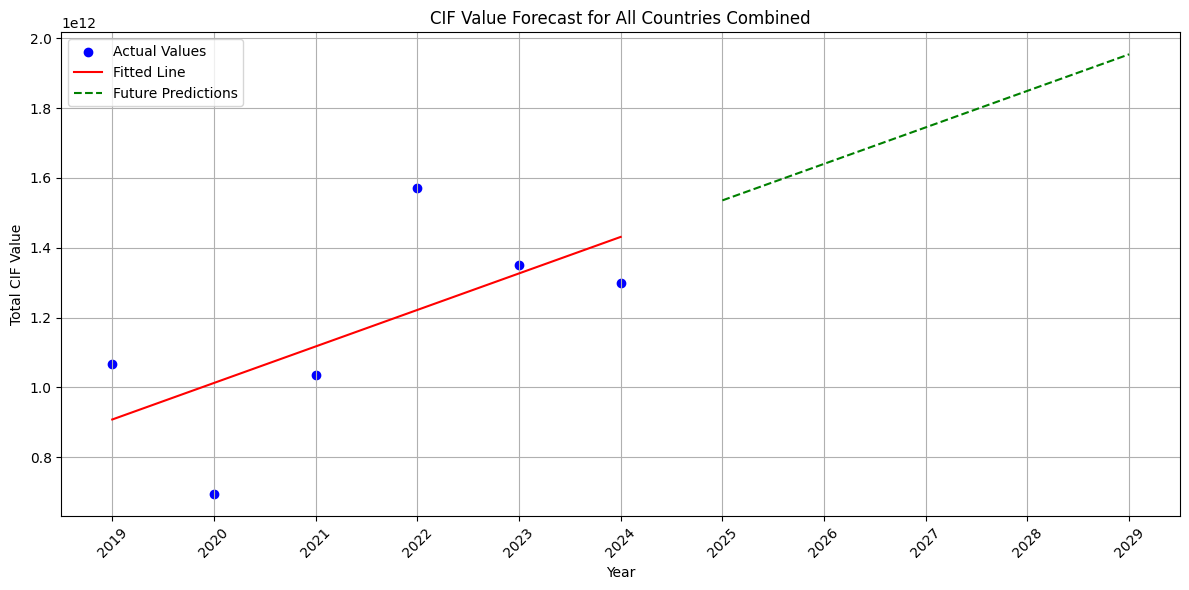

   Year  Predicted CIF Value
0  2025         1.535750e+12
1  2026         1.640408e+12
2  2027         1.745066e+12
3  2028         1.849723e+12
4  2029         1.954381e+12


In [16]:
# Group by year, summing the cifvalue for all countries
grouped_data = combined_df.groupby('refYear')['cifvalue'].sum().reset_index()

# Prepare the feature and target variables
X = grouped_data[['refYear']]
y = grouped_data['cifvalue']

# Fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Forecasting future values (e.g., for the next 5 years)
future_years = pd.DataFrame({'refYear': np.arange(grouped_data['refYear'].max() + 1, grouped_data['refYear'].max() + 6)})
future_predictions = model.predict(future_years)

# Create the plot for historical data and forecast
plt.figure(figsize=(12, 6))
plt.scatter(grouped_data['refYear'], grouped_data['cifvalue'], color='blue', label='Actual Values')
plt.plot(grouped_data['refYear'], model.predict(X), color='red', label='Fitted Line')
plt.plot(future_years['refYear'], future_predictions, color='green', linestyle='--', label='Future Predictions')
plt.title('CIF Value Forecast for All Countries Combined')
plt.xlabel('Year')
plt.ylabel('Total CIF Value')
# Set x-ticks to show all years in the dataset
all_years = np.arange(grouped_data['refYear'].min(), future_years['refYear'].max() + 1)
plt.xticks(all_years, rotation=45)
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Display future predictions
future_results = pd.DataFrame({'Year': future_years['refYear'], 'Predicted CIF Value': future_predictions})
print(future_results)

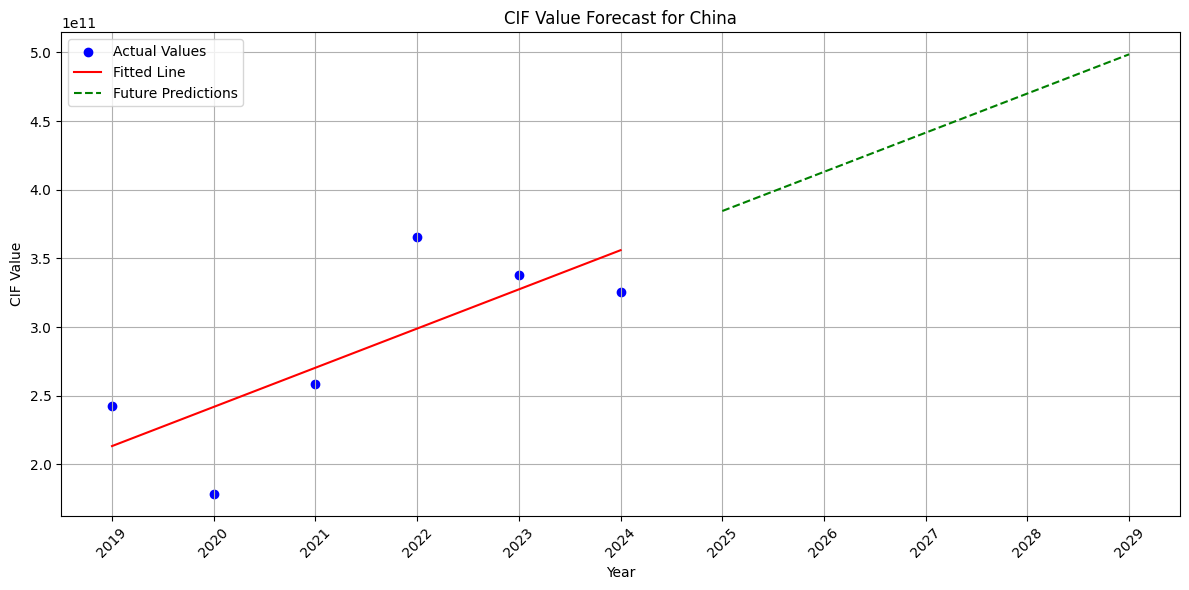

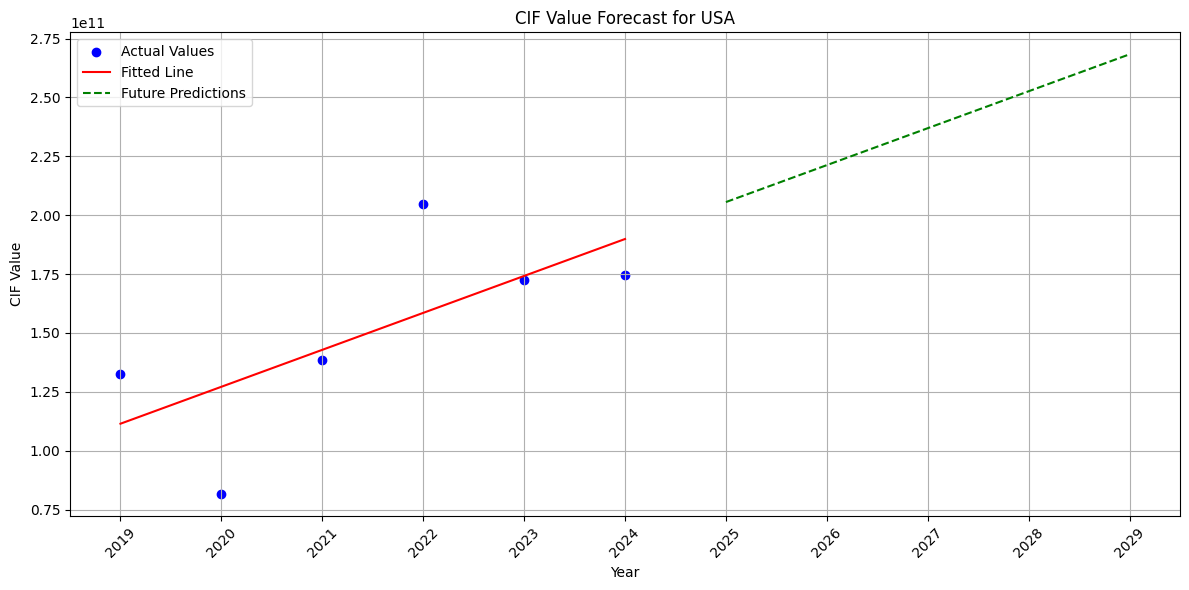

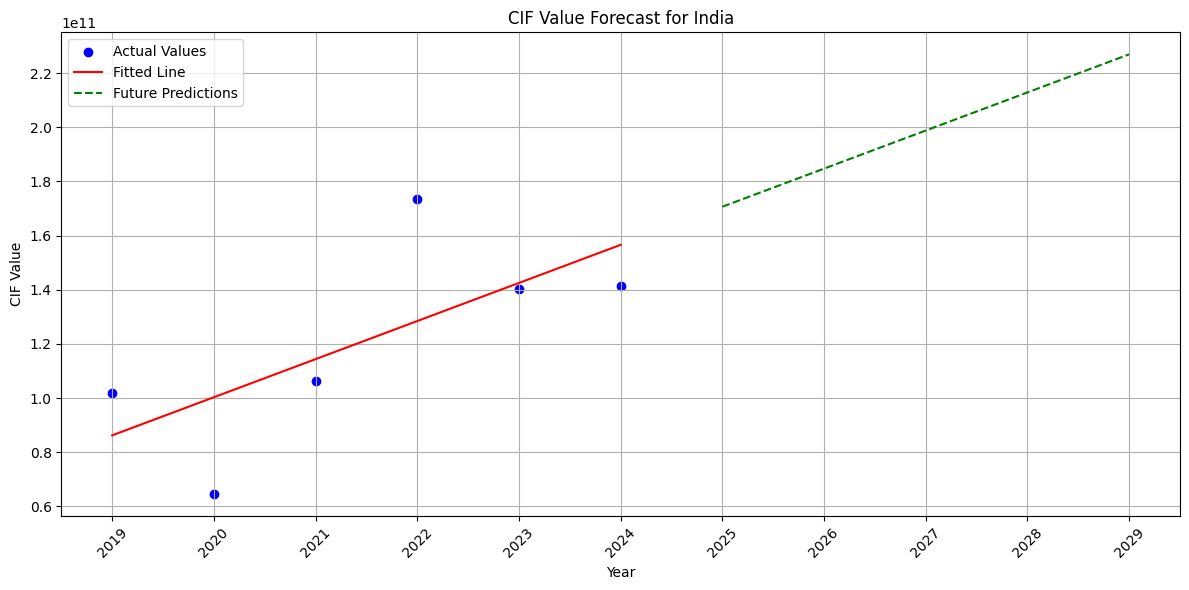

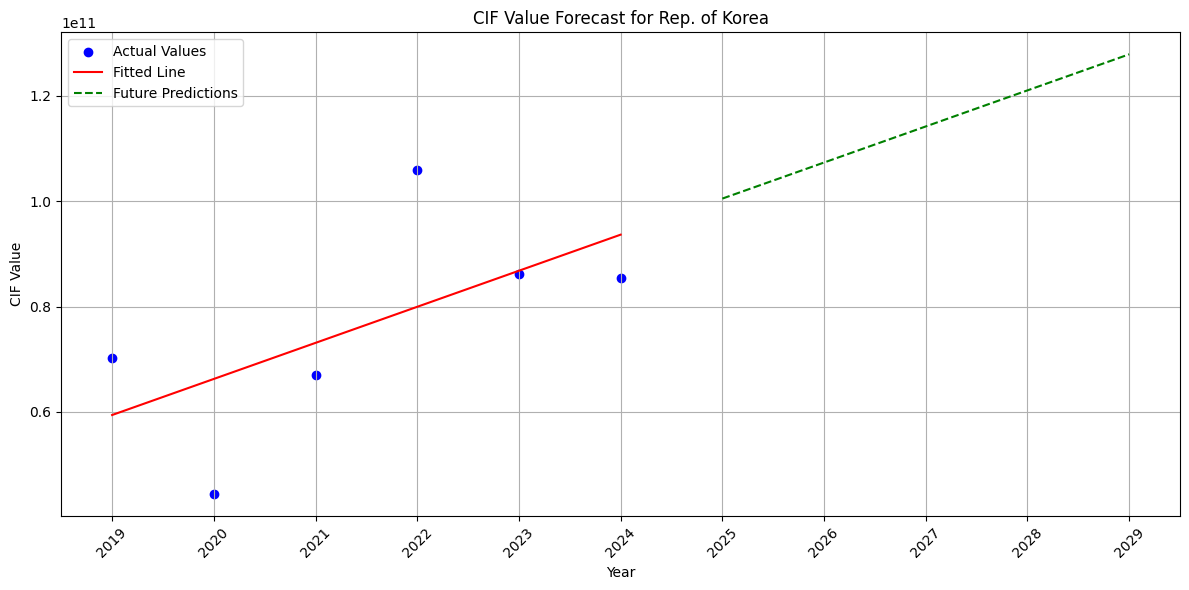

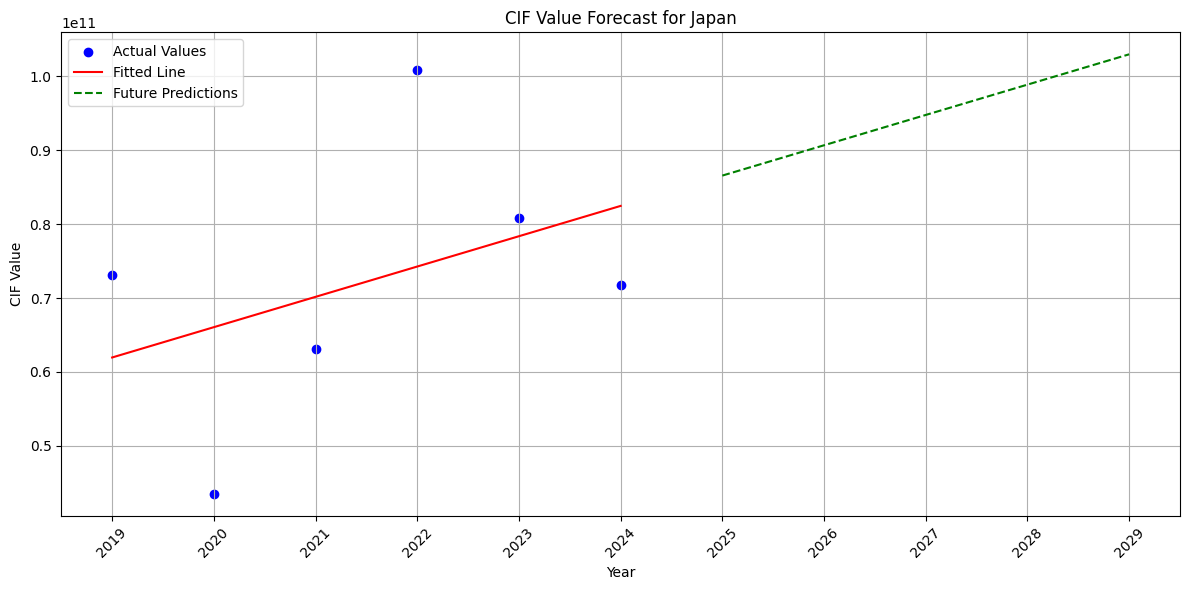

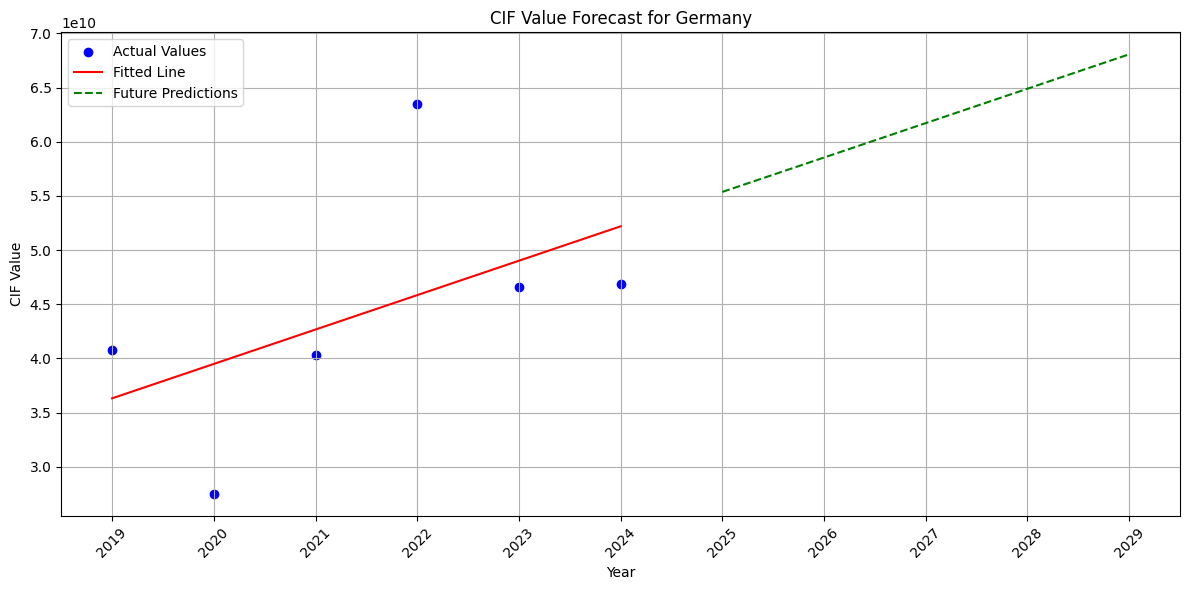

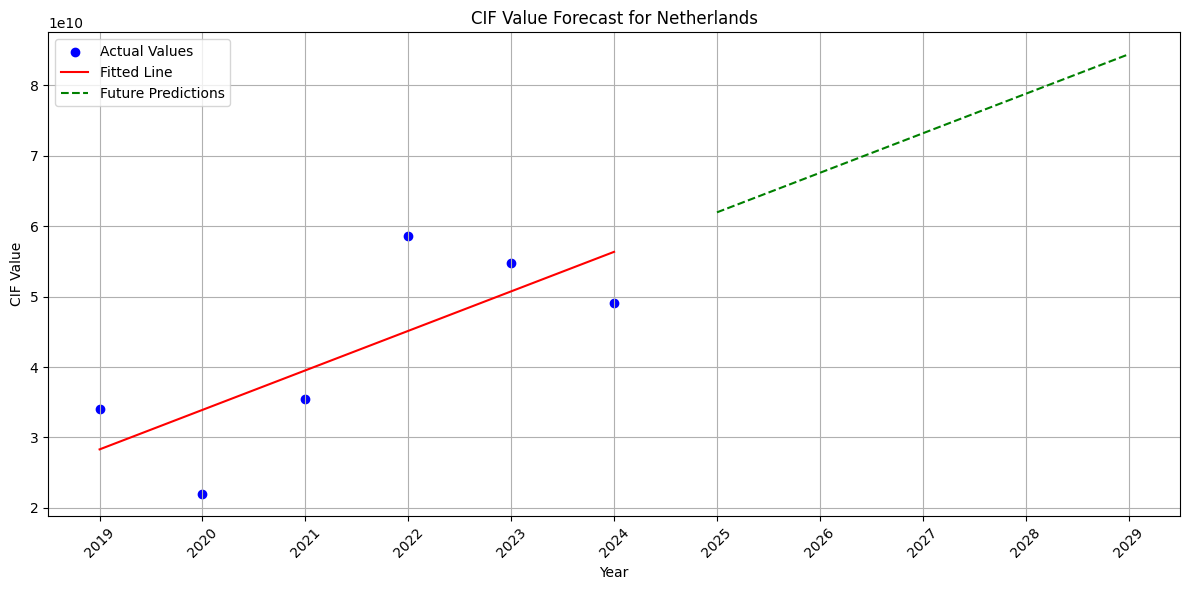

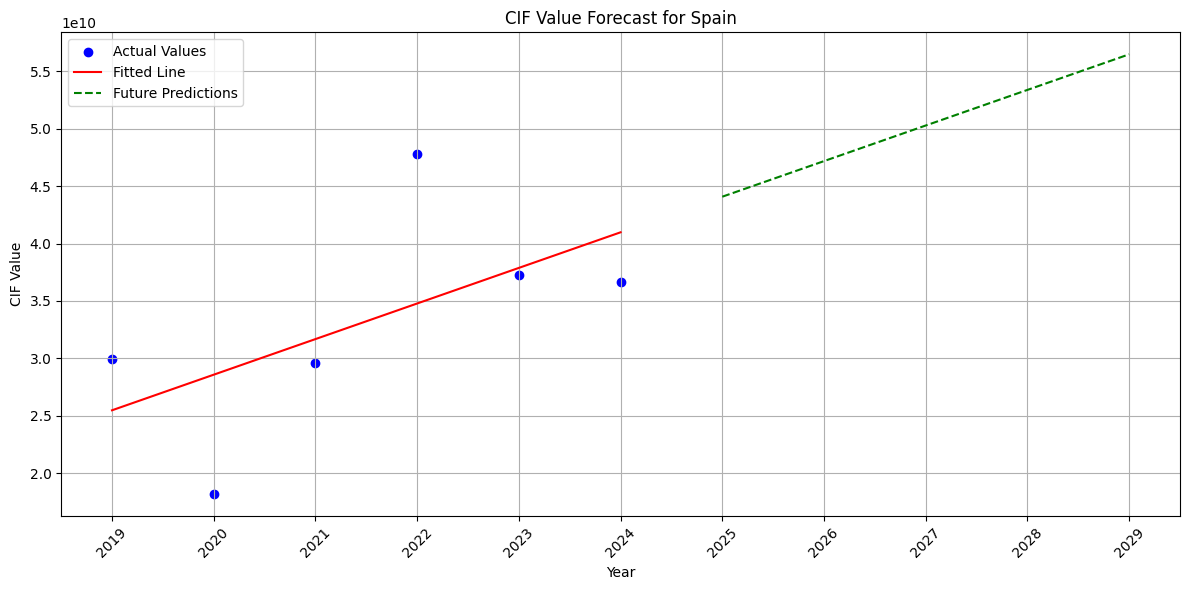

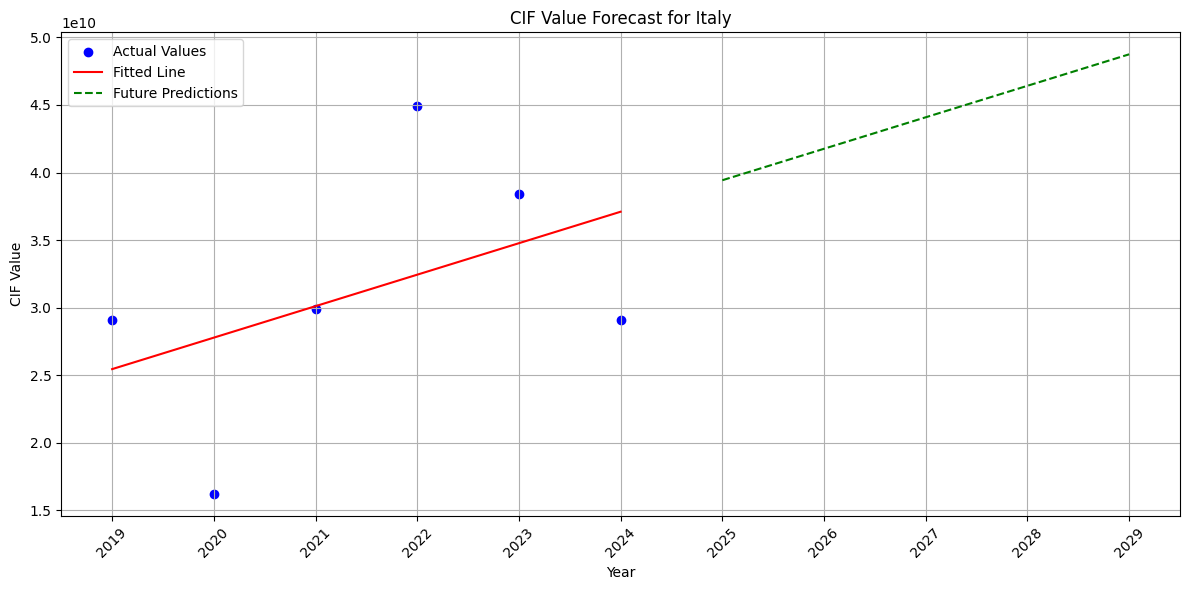

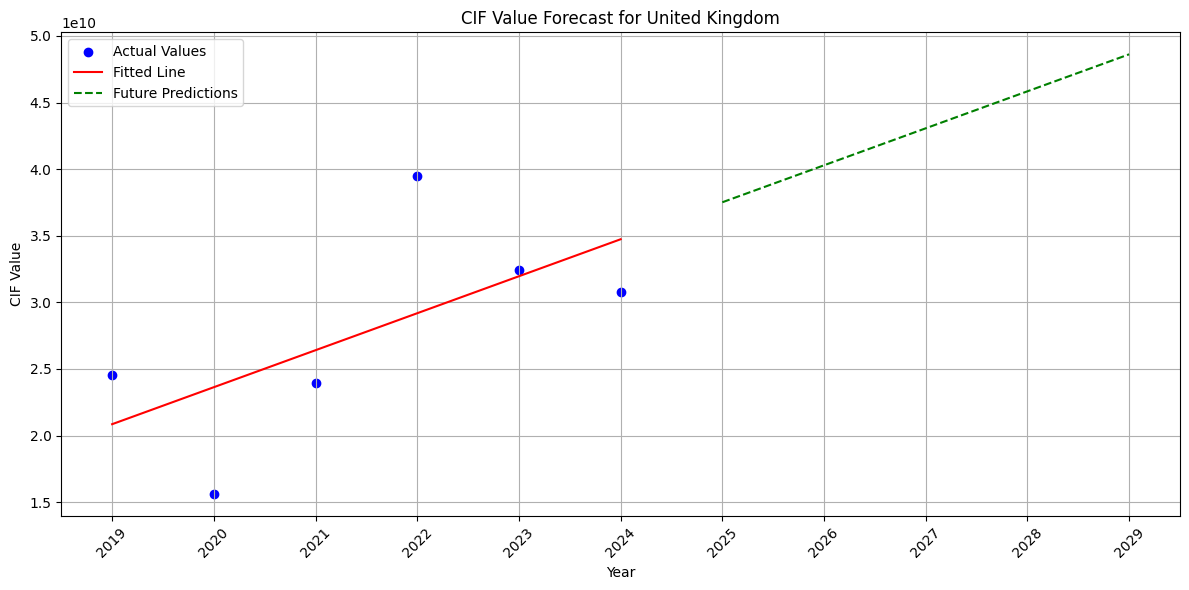

           Country  Year  Predicted CIF Value
0            China  2025         3.844746e+11
1            China  2026         4.130053e+11
2            China  2027         4.415360e+11
3            China  2028         4.700666e+11
4            China  2029         4.985973e+11
5              USA  2025         2.055569e+11
6              USA  2026         2.212422e+11
7              USA  2027         2.369275e+11
8              USA  2028         2.526129e+11
9              USA  2029         2.682982e+11
10           India  2025         1.706397e+11
11           India  2026         1.847096e+11
12           India  2027         1.987795e+11
13           India  2028         2.128495e+11
14           India  2029         2.269194e+11
15   Rep. of Korea  2025         1.004766e+11
16   Rep. of Korea  2026         1.073187e+11
17   Rep. of Korea  2027         1.141608e+11
18   Rep. of Korea  2028         1.210029e+11
19   Rep. of Korea  2029         1.278450e+11
20           Japan  2025         8

In [17]:
# cif value forecast for the top 10 countries

# Group by country and year, summing the cifvalue for each combination
grouped_data = combined_df.groupby(['reporterDesc', 'refYear'])['cifvalue'].sum().reset_index()

# Identify the top 10 countries based on the total CIF value
top_countries = grouped_data.groupby('reporterDesc')['cifvalue'].sum().reset_index()
top_countries = top_countries.sort_values(by='cifvalue', ascending=False).head(10)

# Prepare to store future predictions
future_results = pd.DataFrame()

# Loop through each top country to apply linear regression
for country in top_countries['reporterDesc']:
    country_data = grouped_data[grouped_data['reporterDesc'] == country]

    # Prepare the feature and target variables
    X = country_data[['refYear']]
    y = country_data['cifvalue']

    # Fit the linear regression model
    model = LinearRegression()
    model.fit(X, y)

    # Forecasting future values (e.g., for the next 5 years)
    future_years = pd.DataFrame({'refYear': np.arange(country_data['refYear'].max() + 1, country_data['refYear'].max() + 6)})
    future_predictions = model.predict(future_years)

    # Store future predictions for each country
    future_country_results = pd.DataFrame({'Country': country, 'Year': future_years['refYear'], 'Predicted CIF Value': future_predictions})
    future_results = pd.concat([future_results, future_country_results], ignore_index=True)

    # Plotting the results for each country
    plt.figure(figsize=(12, 6))
    plt.scatter(country_data['refYear'], country_data['cifvalue'], color='blue', label='Actual Values')
    plt.plot(country_data['refYear'], model.predict(X), color='red', label='Fitted Line')
    plt.plot(future_years['refYear'], future_predictions, color='green', linestyle='--', label='Future Predictions')
    plt.title(f'CIF Value Forecast for {country}')
    plt.xlabel('Year')
    plt.ylabel('CIF Value')
    # Set x-ticks to show all years in the dataset
    all_years = np.arange(country_data['refYear'].min(), future_years['refYear'].max() + 1)
    plt.xticks(all_years, rotation=45)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

# Display future predictions for all top countries
print(future_results)

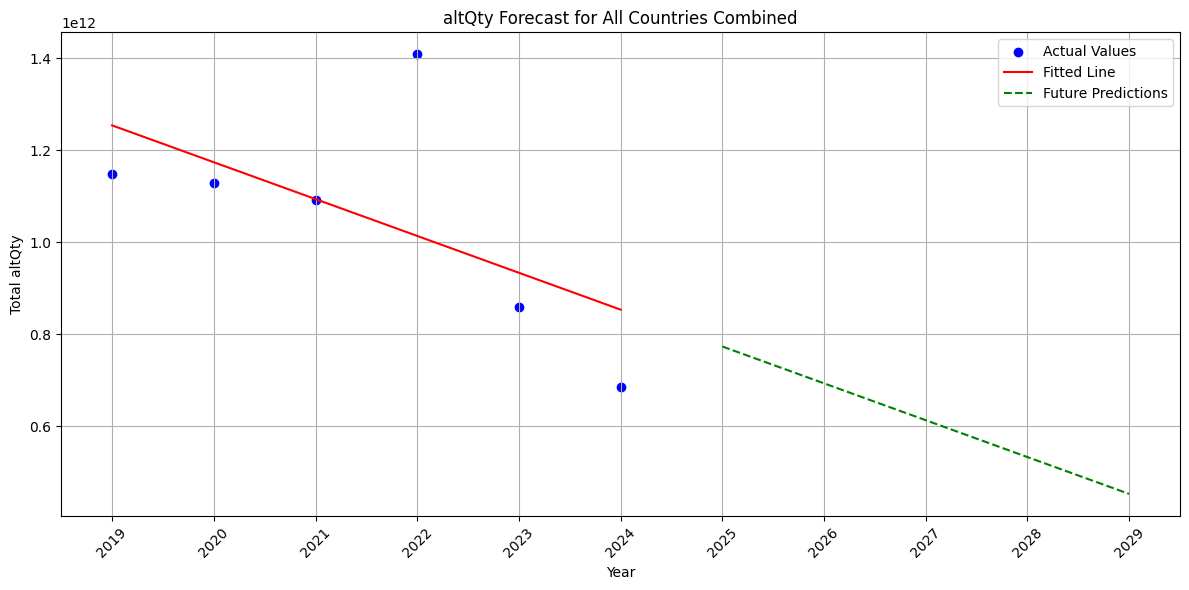

   Year  Predicted altQty
0  2025      7.734330e+11
1  2026      6.932594e+11
2  2027      6.130858e+11
3  2028      5.329122e+11
4  2029      4.527386e+11


In [18]:
# Group by year, summing the altQty for all countries
grouped_data = combined_df.groupby('refYear')['altQty'].sum().reset_index()

# Prepare the feature and target variables
X = grouped_data[['refYear']]
y = grouped_data['altQty']

# Fit the linear regression model
model = LinearRegression()
model.fit(X, y)

# Forecasting future values (e.g., for the next 5 years)
future_years = pd.DataFrame({'refYear': np.arange(grouped_data['refYear'].max() + 1, grouped_data['refYear'].max() + 6)})
future_predictions = model.predict(future_years)

# Create the plot for historical data and forecast
plt.figure(figsize=(12, 6))
plt.scatter(grouped_data['refYear'], grouped_data['altQty'], color='blue', label='Actual Values')
plt.plot(grouped_data['refYear'], model.predict(X), color='red', label='Fitted Line')
plt.plot(future_years['refYear'], future_predictions, color='green', linestyle='--', label='Future Predictions')
plt.title('altQty Forecast for All Countries Combined')
plt.xlabel('Year')
plt.ylabel('Total altQty')
all_years = np.arange(country_data['refYear'].min(), future_years['refYear'].max() + 1)
plt.xticks(all_years, rotation=45)

plt.legend()
plt.grid()
plt.tight_layout()
plt.show()

# Display future predictions
future_results = pd.DataFrame({'Year': future_years['refYear'], 'Predicted altQty': future_predictions})
print(future_results)

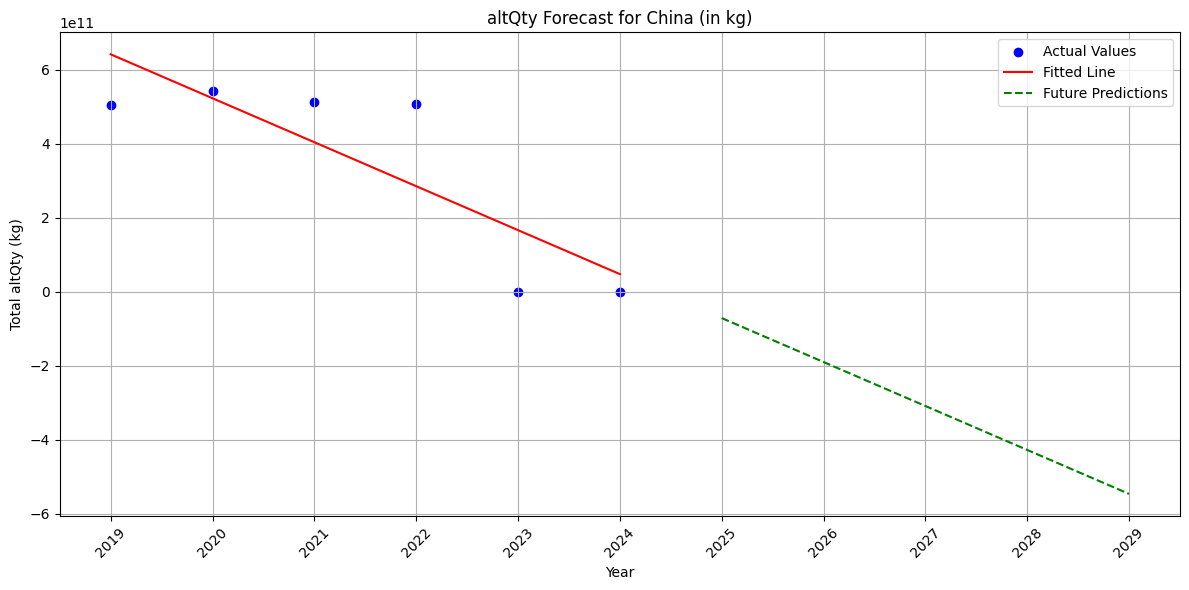

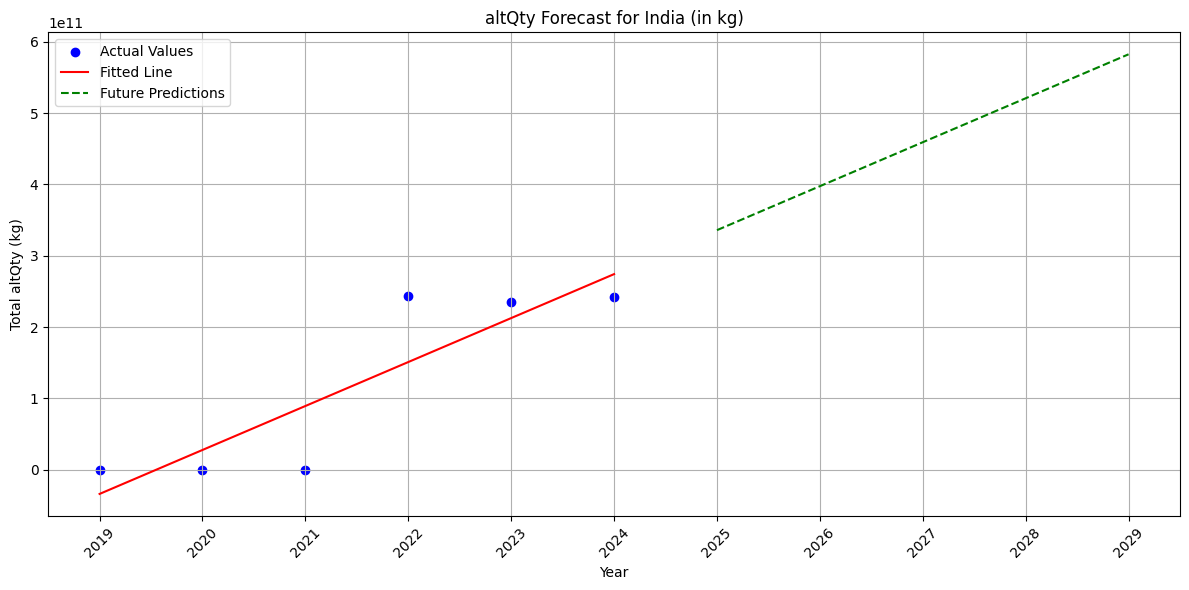

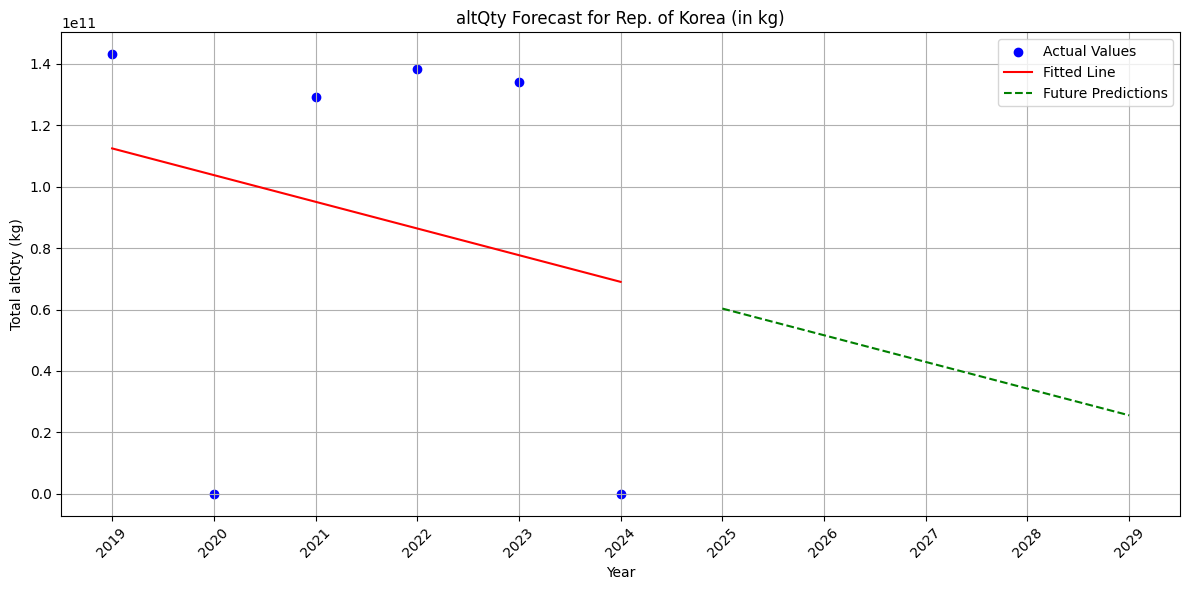

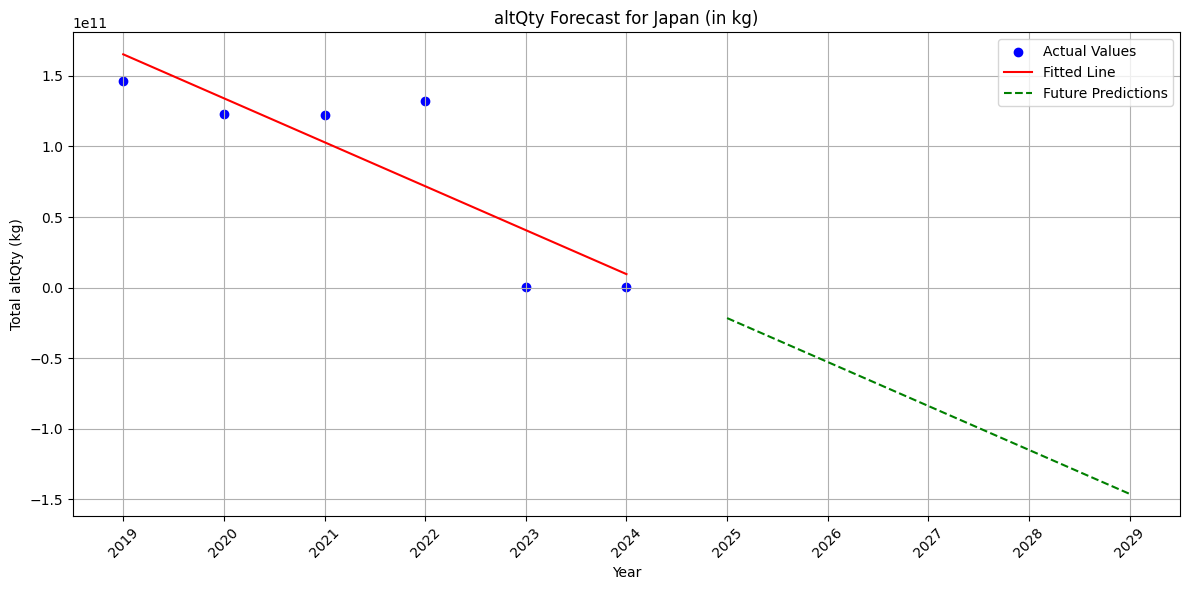

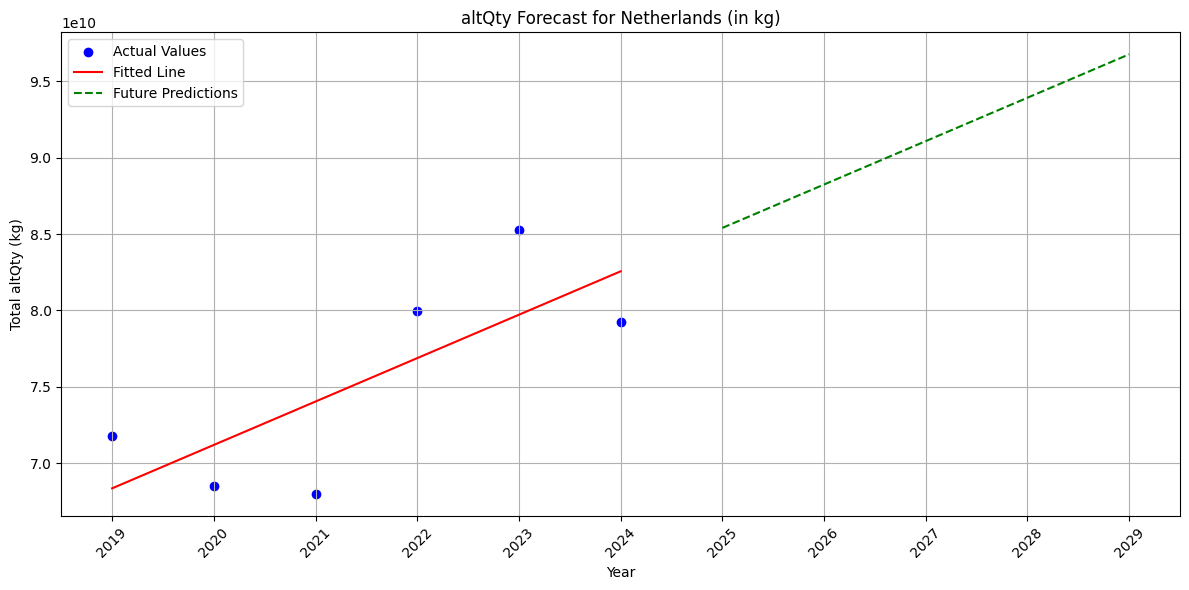

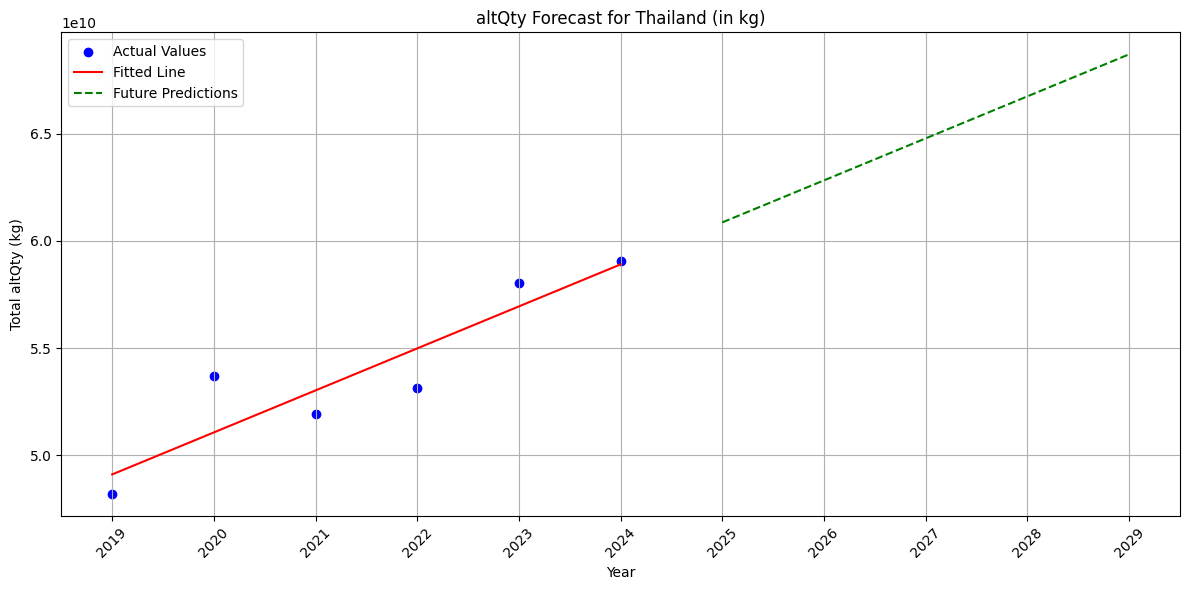

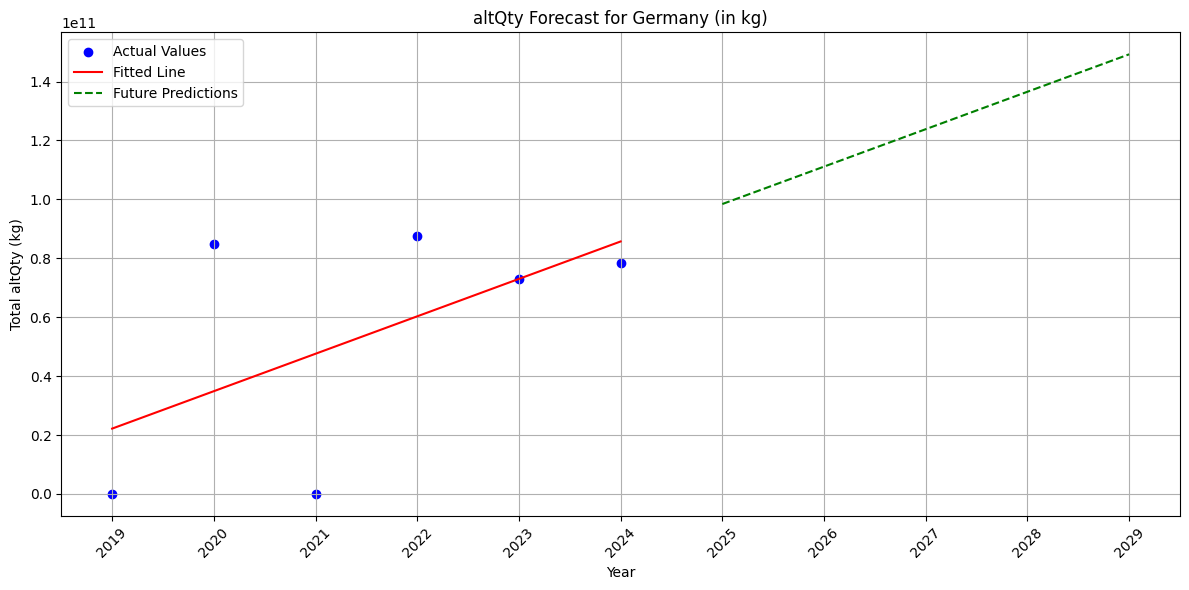

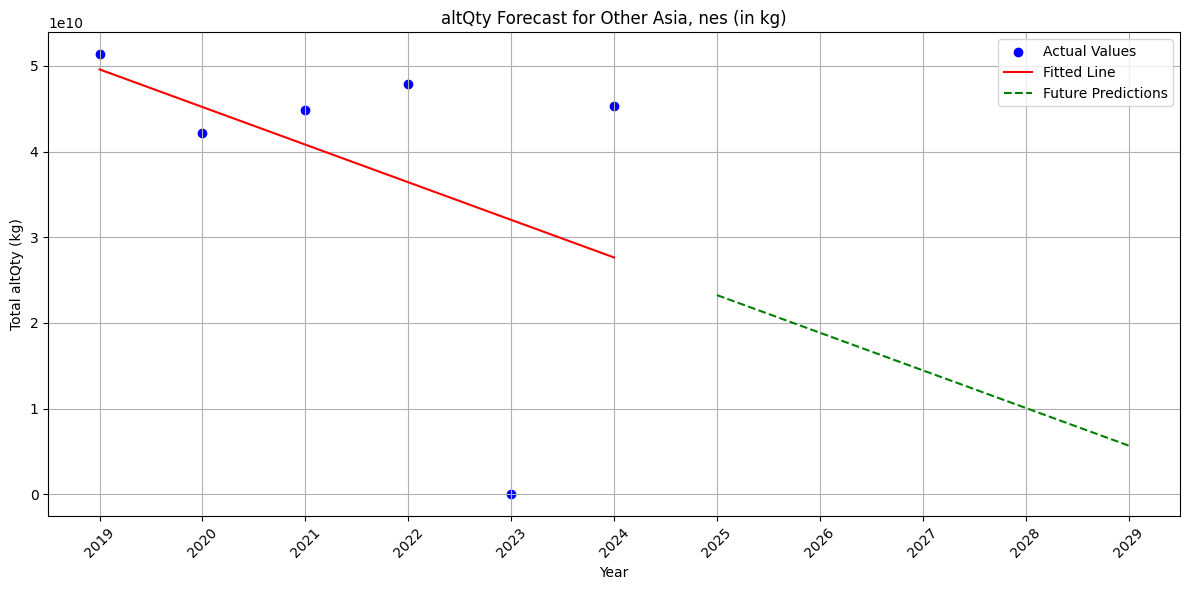

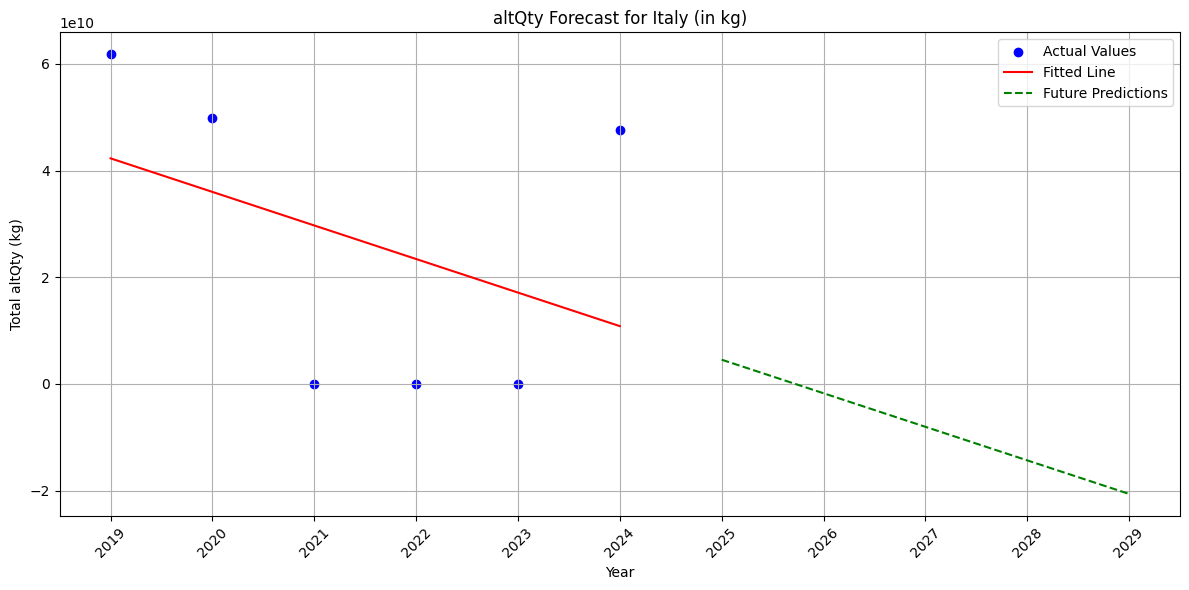

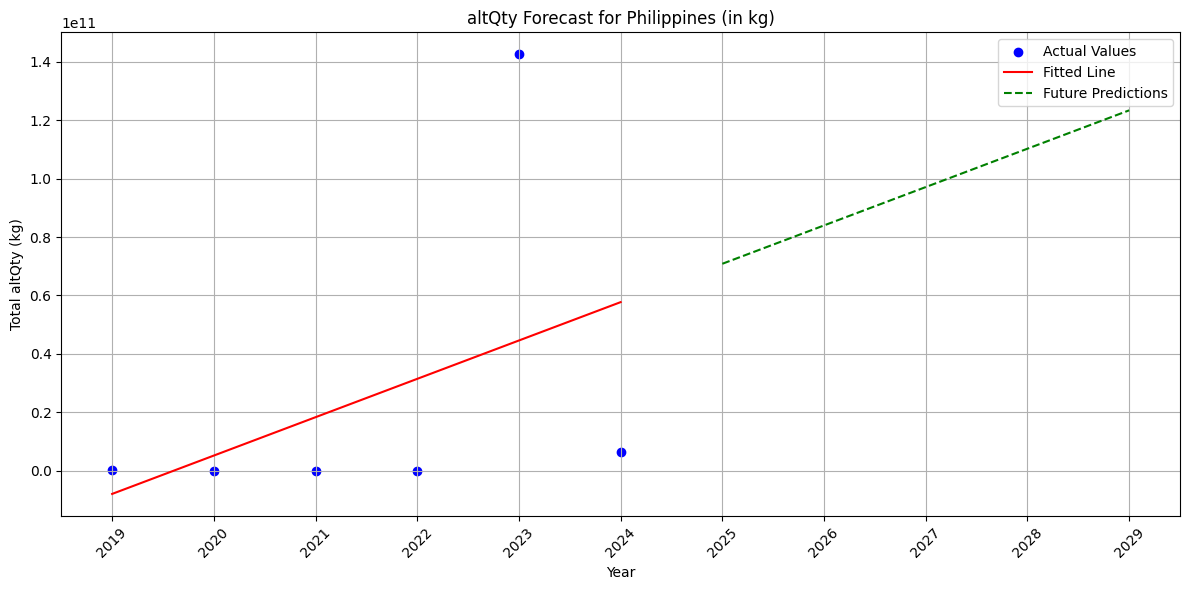

            Country  Year  Predicted altQty (kg)
0             China  2025          -7.109116e+10
1             China  2026          -1.899211e+11
2             China  2027          -3.087510e+11
3             China  2028          -4.275809e+11
4             China  2029          -5.464107e+11
5             India  2025           3.358360e+11
6             India  2026           3.974884e+11
7             India  2027           4.591407e+11
8             India  2028           5.207931e+11
9             India  2029           5.824455e+11
10    Rep. of Korea  2025           6.032090e+10
11    Rep. of Korea  2026           5.163480e+10
12    Rep. of Korea  2027           4.294870e+10
13    Rep. of Korea  2028           3.426259e+10
14    Rep. of Korea  2029           2.557649e+10
15            Japan  2025          -2.165002e+10
16            Japan  2026          -5.281629e+10
17            Japan  2027          -8.398256e+10
18            Japan  2028          -1.151488e+11
19            Japan 

In [19]:


# Group by country and year, summing the altQty (in kg) for each combination
grouped_data = combined_df.groupby(['reporterDesc', 'refYear'])['altQty'].sum().reset_index()

# Identify the top 10 countries based on the total altQty
top_countries = grouped_data.groupby('reporterDesc')['altQty'].sum().reset_index()
top_countries = top_countries.sort_values(by='altQty', ascending=False).head(10)

# Prepare to store future predictions
future_results = pd.DataFrame()

# Loop through each top country to apply linear regression
for country in top_countries['reporterDesc']:
    country_data = grouped_data[grouped_data['reporterDesc'] == country]

    # Prepare the feature and target variables
    X = country_data[['refYear']]
    y = country_data['altQty']

    # Fit the linear regression model
    model = LinearRegression()
    model.fit(X, y)

    # Forecasting future values (e.g., for the next 5 years)
    future_years = pd.DataFrame({'refYear': np.arange(country_data['refYear'].max() + 1, country_data['refYear'].max() + 6)})
    future_predictions = model.predict(future_years)

    # Store future predictions for each country
    future_country_results = pd.DataFrame({'Country': country, 'Year': future_years['refYear'], 'Predicted altQty (kg)': future_predictions})
    future_results = pd.concat([future_results, future_country_results], ignore_index=True)

    # Plotting the results for each country
    plt.figure(figsize=(12, 6))
    plt.scatter(country_data['refYear'], country_data['altQty'], color='blue', label='Actual Values')
    plt.plot(country_data['refYear'], model.predict(X), color='red', label='Fitted Line')
    plt.plot(future_years['refYear'], future_predictions, color='green', linestyle='--', label='Future Predictions')
    plt.title(f'altQty Forecast for {country} (in kg)')
    plt.xlabel('Year')
    plt.ylabel('Total altQty (kg)')
    
    # Set x-ticks to show all years in the dataset
    all_years = np.arange(country_data['refYear'].min(), future_years['refYear'].max() + 1)
    plt.xticks(all_years, rotation=45)
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

# Display future predictions for all top countries
print(future_results)
